# SafeGuard Vision AI - Extracción de Keypoints con BlazePose
## MIT Global Teaching Labs
---
**Autor:** The Outliers  
**Fecha:** Enero 2026

Este notebook extrae los **33 keypoints del cuerpo humano** usando **MediaPipe PoseLandmarker** (nueva API).

###  Dataset: ~16,930 imágenes
###  Tiempo estimado: ~25-35 minutos

---
##  Paso 1: Montar Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print(" Google Drive montado")

Mounted at /content/drive
 Google Drive montado


---
##  Paso 2: Instalar MediaPipe y descargar modelo

In [3]:
# Instalar MediaPipe
!pip install mediapipe -q

# Descargar modelo de pose (BlazePose)
!wget -q -O pose_landmarker_heavy.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task

print(" MediaPipe instalado")
print(" Modelo pose_landmarker_heavy descargado")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.7 MB/s eta 0:00:00
 MediaPipe instalado
 Modelo pose_landmarker_heavy descargado


---
##  Paso 3: Configurar rutas


In [4]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                     CONFIGURA TUS RUTAS AQUÍ                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Dataset le2i (estructura: carpeta/subcarpetas/imágenes)
DATASET_LE2I = "/content/drive/MyDrive/le2i"

# Dataset ur_fall (estructura: carpeta/emergencias|simuladas/imágenes)
DATASET_URFALL = "/content/drive/MyDrive/ur_fall/frames_from_videos"

# Carpeta de salida para los CSVs
OUTPUT_FOLDER = "/content/drive/MyDrive/safeguard_keypoints"

# Ruta al modelo descargado
MODEL_PATH = "/content/pose_landmarker_heavy.task"

print(" Configuración de rutas:")
print(f"   Dataset le2i:    {DATASET_LE2I}")
print(f"   Dataset ur_fall: {DATASET_URFALL}")
print(f"   Output:          {OUTPUT_FOLDER}")

 Configuración de rutas:
   Dataset le2i:    /content/drive/MyDrive/le2i
   Dataset ur_fall: /content/drive/MyDrive/ur_fall/frames_from_videos
   Output:          /content/drive/MyDrive/safeguard_keypoints


---
##  Paso 4: Cargar librerías y configurar MediaPipe

In [5]:
import cv2
import numpy as np
import pandas as pd
import os
import json
from datetime import datetime
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# Nueva API de MediaPipe
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Nombres de los 33 keypoints de BlazePose
KEYPOINT_NAMES = [
    'nose',
    'left_eye_inner', 'left_eye', 'left_eye_outer',
    'right_eye_inner', 'right_eye', 'right_eye_outer',
    'left_ear', 'right_ear',
    'mouth_left', 'mouth_right',
    'left_shoulder', 'right_shoulder',
    'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist',
    'left_pinky', 'right_pinky',
    'left_index', 'right_index',
    'left_thumb', 'right_thumb',
    'left_hip', 'right_hip',
    'left_knee', 'right_knee',
    'left_ankle', 'right_ankle',
    'left_heel', 'right_heel',
    'left_foot_index', 'right_foot_index'
]

print(f" MediaPipe cargado")
print(f"   Versión: {mp.__version__}")
print(f"   Keypoints: {len(KEYPOINT_NAMES)} puntos")

 MediaPipe cargado
   Versión: 0.10.31
   Keypoints: 33 puntos


In [6]:
# Configurar el PoseLandmarker (nueva API)
base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=False,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

# Crear detector
detector = vision.PoseLandmarker.create_from_options(options)
print(" PoseLandmarker inicializado")

 PoseLandmarker inicializado


In [7]:
def extract_keypoints(image_path, detector):
    """
    Extrae los 33 keypoints de una imagen usando PoseLandmarker.

    Returns:
        dict con keypoints o None si no detecta persona
    """
    try:
        # Cargar imagen con la nueva API
        image = mp.Image.create_from_file(image_path)

        # Detectar pose
        detection_result = detector.detect(image)

        # Si no detecta pose, retornar None
        if not detection_result.pose_landmarks or len(detection_result.pose_landmarks) == 0:
            return None

        # Extraer keypoints del primer pose detectado
        landmarks = detection_result.pose_landmarks[0]

        keypoints = {}
        for idx, landmark in enumerate(landmarks):
            name = KEYPOINT_NAMES[idx]
            keypoints[f"{name}_x"] = landmark.x          # 0-1 normalizado
            keypoints[f"{name}_y"] = landmark.y          # 0-1 normalizado
            keypoints[f"{name}_z"] = landmark.z          # profundidad
            keypoints[f"{name}_vis"] = landmark.visibility  # 0-1 visibilidad

        return keypoints

    except Exception as e:
        return None


def classify_le2i(folder_name):
    """
    Clasifica una carpeta del dataset le2i.
    Returns: (label, label_name)
    """
    name_lower = folder_name.lower()
    if name_lower.startswith('fall'):
        return 1, 'fall'
    elif name_lower.startswith('likefall'):
        return 1, 'fall'
    else:
        return 0, 'adl'


def classify_urfall(folder_name):
    """
    Clasifica una carpeta del dataset ur_fall.
    Returns: (label, label_name)
    """
    name_lower = folder_name.lower()
    if 'emergencia' in name_lower or 'fall' in name_lower:
        return 1, 'fall'
    else:
        return 0, 'adl'


def get_all_images(dataset_path, dataset_name):
    """
    Obtiene lista de todas las imágenes con su clasificación.
    Returns: lista de dicts
    """
    images = []
    extensions = ('.jpg', '.jpeg', '.png', '.bmp')

    if not os.path.exists(dataset_path):
        print(f" No existe: {dataset_path}")
        return images

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(extensions):
                image_path = os.path.join(root, file)
                parent_folder = os.path.basename(root)

                if dataset_name == 'le2i':
                    label, label_name = classify_le2i(parent_folder)
                else:
                    label, label_name = classify_urfall(parent_folder)

                images.append({
                    'path': image_path,
                    'filename': file,
                    'folder': parent_folder,
                    'label': label,
                    'label_name': label_name,
                    'dataset': dataset_name
                })

    return images

print(" Funciones cargadas")

 Funciones cargadas


---
##  Paso 5: Verificar datasets

In [8]:
print(" Verificando datasets...\n")

images_le2i = get_all_images(DATASET_LE2I, 'le2i')
images_urfall = get_all_images(DATASET_URFALL, 'ur_fall')

all_images = images_le2i + images_urfall

falls = sum(1 for img in all_images if img['label'] == 1)
adls = sum(1 for img in all_images if img['label'] == 0)

print("╔" + "═"*50 + "╗")
print("║" + "  RESUMEN DE IMÁGENES A PROCESAR ".center(50) + "║")
print("╠" + "═"*50 + "╣")
print(f"║   Dataset le2i:      {len(images_le2i):>6} imágenes{' '*13}║")
print(f"║   Dataset ur_fall:   {len(images_urfall):>6} imágenes{' '*13}║")
print("╠" + "═"*50 + "╣")
print(f"║   Caídas (label=1):  {falls:>6} imágenes{' '*13}║")
print(f"║   ADL (label=0):     {adls:>6} imágenes{' '*13}║")
print("╠" + "═"*50 + "╣")
print(f"║   TOTAL:             {len(all_images):>6} imágenes{' '*13}║")
print("╚" + "═"*50 + "╝")

tiempo_est = len(all_images) * 0.1 / 60
print(f"\n Tiempo estimado: ~{tiempo_est:.0f} minutos")

 Verificando datasets...

╔══════════════════════════════════════════════════╗
║          RESUMEN DE IMÁGENES A PROCESAR          ║
╠══════════════════════════════════════════════════╣
║   Dataset le2i:       12432 imágenes             ║
║   Dataset ur_fall:     4498 imágenes             ║
╠══════════════════════════════════════════════════╣
║   Caídas (label=1):    1921 imágenes             ║
║   ADL (label=0):      15009 imágenes             ║
╠══════════════════════════════════════════════════╣
║   TOTAL:              16930 imágenes             ║
╚══════════════════════════════════════════════════╝

 Tiempo estimado: ~28 minutos


---
##  Paso 6: (Opcional) Test con una imagen

 Probando con: 174.jpg
   Carpeta: home_v28c1
   Label: adl

 Keypoints extraídos: 132 valores
   (33 puntos × 4 valores = 132 features)

   Nariz:    x=0.320, y=0.378
   Hombro L: x=0.352, y=0.382
   Cadera L: x=0.437, y=0.427


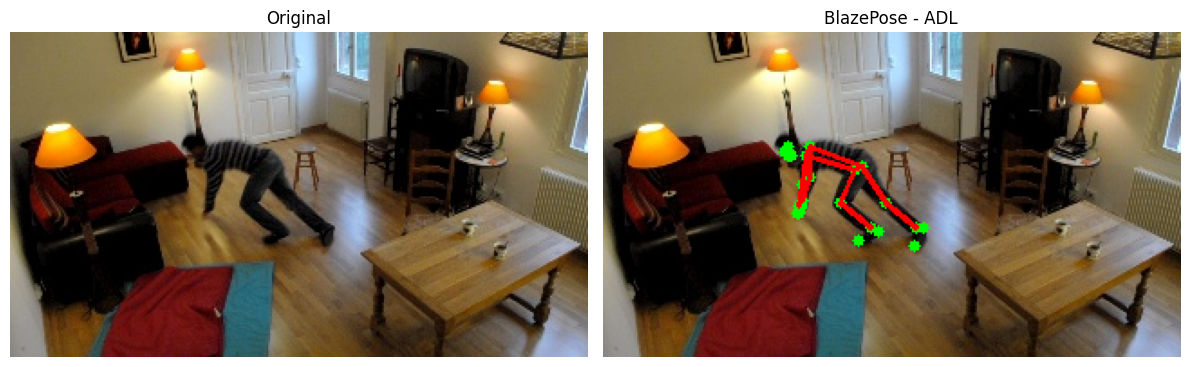

In [9]:
import matplotlib.pyplot as plt

if all_images:
    test_image = all_images[0]

    print(f" Probando con: {test_image['filename']}")
    print(f"   Carpeta: {test_image['folder']}")
    print(f"   Label: {test_image['label_name']}")

    keypoints = extract_keypoints(test_image['path'], detector)

    if keypoints:
        print(f"\n Keypoints extraídos: {len(keypoints)} valores")
        print(f"   (33 puntos × 4 valores = 132 features)")
        print(f"\n   Nariz:    x={keypoints['nose_x']:.3f}, y={keypoints['nose_y']:.3f}")
        print(f"   Hombro L: x={keypoints['left_shoulder_x']:.3f}, y={keypoints['left_shoulder_y']:.3f}")
        print(f"   Cadera L: x={keypoints['left_hip_x']:.3f}, y={keypoints['left_hip_y']:.3f}")

        # Visualizar
        image = cv2.imread(test_image['path'])
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image_rgb.shape[:2]

        # Dibujar keypoints manualmente
        annotated = image_rgb.copy()
        for name in KEYPOINT_NAMES:
            x = int(keypoints[f"{name}_x"] * w)
            y = int(keypoints[f"{name}_y"] * h)
            cv2.circle(annotated, (x, y), 3, (0, 255, 0), -1)

        # Dibujar conexiones principales
        connections = [
            ('left_shoulder', 'right_shoulder'),
            ('left_shoulder', 'left_elbow'),
            ('left_elbow', 'left_wrist'),
            ('right_shoulder', 'right_elbow'),
            ('right_elbow', 'right_wrist'),
            ('left_shoulder', 'left_hip'),
            ('right_shoulder', 'right_hip'),
            ('left_hip', 'right_hip'),
            ('left_hip', 'left_knee'),
            ('left_knee', 'left_ankle'),
            ('right_hip', 'right_knee'),
            ('right_knee', 'right_ankle'),
        ]
        for p1, p2 in connections:
            x1 = int(keypoints[f"{p1}_x"] * w)
            y1 = int(keypoints[f"{p1}_y"] * h)
            x2 = int(keypoints[f"{p2}_x"] * w)
            y2 = int(keypoints[f"{p2}_y"] * h)
            cv2.line(annotated, (x1, y1), (x2, y2), (255, 0, 0), 2)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(image_rgb)
        axes[0].set_title('Original')
        axes[0].axis('off')

        axes[1].imshow(annotated)
        axes[1].set_title(f'BlazePose - {test_image["label_name"].upper()}')
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("❌ No se detectó persona en la imagen")

---
##  Paso 7:  EXTRAER KEYPOINTS DE TODAS LAS IMÁGENES

 **Esto tomará ~25-35 minutos**

In [10]:
import time

print("\n")
print("╔" + "═"*58 + "╗")
print("║" + "  SafeGuard Vision AI - Extracción de Keypoints ".center(58) + "║")
print("║" + " BlazePose (MediaPipe) ".center(58) + "║")
print("╚" + "═"*58 + "╝")

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

all_data = []
failed_images = []

start_time = time.time()

for img_info in tqdm(all_images, desc="Extrayendo keypoints"):
    try:
        keypoints = extract_keypoints(img_info['path'], detector)

        if keypoints:
            row = {
                'filename': img_info['filename'],
                'folder': img_info['folder'],
                'dataset': img_info['dataset'],
                'label': img_info['label'],
                'label_name': img_info['label_name']
            }
            row.update(keypoints)
            all_data.append(row)
        else:
            failed_images.append(img_info['path'])

    except Exception as e:
        failed_images.append(img_info['path'])

elapsed_time = time.time() - start_time

print(f"\n Procesamiento completado en {elapsed_time/60:.1f} minutos")
print(f"   Exitosos: {len(all_data)}")
print(f"   Fallidos: {len(failed_images)}")



╔══════════════════════════════════════════════════════════╗
║       SafeGuard Vision AI - Extracción de Keypoints      ║
║                  BlazePose (MediaPipe)                   ║
╚══════════════════════════════════════════════════════════╝


Extrayendo keypoints:   0%|          | 0/16930 [00:00<?, ?it/s]

KeyboardInterrupt: 

---
##  Paso 8: Guardar CSV y resumen

In [ ]:
df = pd.DataFrame(all_data)

csv_path = os.path.join(OUTPUT_FOLDER, "keypoints_dataset.csv")
df.to_csv(csv_path, index=False)

if failed_images:
    failed_path = os.path.join(OUTPUT_FOLDER, "failed_images.txt")
    with open(failed_path, 'w') as f:
        for path in failed_images:
            f.write(path + '\n')

summary = {
    "created": datetime.now().isoformat(),
    "project": "SafeGuard Vision AI",
    "author": "Christian Cajusol - MIT Global Teaching Labs",
    "model": "BlazePose (MediaPipe PoseLandmarker)",
    "mediapipe_version": mp.__version__,
    "statistics": {
        "total_processed": len(all_data),
        "failed": len(failed_images),
        "success_rate": f"{len(all_data)/(len(all_data)+len(failed_images))*100:.1f}%",
        "falls": int(df[df['label']==1].shape[0]),
        "adl": int(df[df['label']==0].shape[0]),
        "by_dataset": df.groupby('dataset').size().to_dict()
    },
    "features": {
        "keypoints": 33,
        "values_per_keypoint": 4,
        "total_features": 132
    },
    "processing_time_minutes": round(elapsed_time/60, 1)
}

json_path = os.path.join(OUTPUT_FOLDER, "keypoints_summary.json")
with open(json_path, 'w') as f:
    json.dump(summary, f, indent=2)

print("\n")
print("╔" + "═"*58 + "╗")
print("║" + "  EXTRACCIÓN COMPLETADA ".center(58) + "║")
print("╠" + "═"*58 + "╣")
print(f"║   Imágenes procesadas: {len(all_data):>10}{' '*21}║")
print(f"║   Imágenes fallidas:   {len(failed_images):>10}{' '*21}║")
print("╠" + "═"*58 + "╣")
print(f"║   Caídas (label=1):    {summary['statistics']['falls']:>10}{' '*21}║")
print(f"║   ADL (label=0):       {summary['statistics']['adl']:>10}{' '*21}║")
print("╠" + "═"*58 + "╣")
print(f"║   CSV:  keypoints_dataset.csv{' '*24}║")
print(f"║   JSON: keypoints_summary.json{' '*23}║")
print(f"║   Ruta: {OUTPUT_FOLDER[-46:]:<47}║")
print("╚" + "═"*58 + "╝")

---
##  Paso 9: Explorar el dataset

In [ ]:
print(" ESTRUCTURA DEL DATASET DE KEYPOINTS\n")

print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nDistribución por clase:")
print(df['label_name'].value_counts())

print("\nDistribución por dataset:")
print(df.groupby(['dataset', 'label_name']).size().unstack(fill_value=0))

print("\n\nPrimeras 5 filas:")
display(df[['filename', 'dataset', 'label_name', 'nose_x', 'nose_y', 'left_shoulder_x', 'left_hip_y']].head())

---
##  Paso 10: Visualizar distribución

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(' SafeGuard Vision AI - Análisis de Keypoints', fontsize=14, fontweight='bold')

# 1. Distribución de clases
ax1 = axes[0, 0]
colors = ['#2ecc71', '#e74c3c']
df['label_name'].value_counts().plot(kind='bar', ax=ax1, color=colors)
ax1.set_title('Distribución de Clases')
ax1.set_xlabel('Clase')
ax1.set_ylabel('Cantidad')
ax1.tick_params(axis='x', rotation=0)

# 2. Posición Y de la nariz
ax2 = axes[0, 1]
df[df['label_name']=='adl']['nose_y'].hist(ax=ax2, alpha=0.7, label='ADL', color='#2ecc71', bins=30)
df[df['label_name']=='fall']['nose_y'].hist(ax=ax2, alpha=0.7, label='Caída', color='#e74c3c', bins=30)
ax2.set_title('Posición Y de Nariz (0=arriba, 1=abajo)')
ax2.set_xlabel('nose_y')
ax2.legend()

# 3. Diferencia nariz-cadera
ax3 = axes[1, 0]
df['torso_angle'] = df['nose_y'] - (df['left_hip_y'] + df['right_hip_y']) / 2
df[df['label_name']=='adl']['torso_angle'].hist(ax=ax3, alpha=0.7, label='ADL', color='#2ecc71', bins=30)
df[df['label_name']=='fall']['torso_angle'].hist(ax=ax3, alpha=0.7, label='Caída', color='#e74c3c', bins=30)
ax3.set_title('Diferencia Y (Nariz - Cadera)')
ax3.set_xlabel('Negativo = Cabeza arriba | Positivo = Cabeza abajo')
ax3.legend()

# 4. Scatter nariz vs cadera
ax4 = axes[1, 1]
adl_data = df[df['label_name']=='adl']
fall_data = df[df['label_name']=='fall']
ax4.scatter(adl_data['nose_y'], (adl_data['left_hip_y']+adl_data['right_hip_y'])/2,
            alpha=0.3, label='ADL', color='#2ecc71', s=10)
ax4.scatter(fall_data['nose_y'], (fall_data['left_hip_y']+fall_data['right_hip_y'])/2,
            alpha=0.3, label='Caída', color='#e74c3c', s=10)
ax4.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Diagonal')
ax4.set_title('Nariz Y vs Cadera Y')
ax4.set_xlabel('Nariz Y')
ax4.set_ylabel('Cadera Y')
ax4.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'keypoints_analysis.png'), dpi=150)
plt.show()

print(f"\n Gráfico guardado en: {OUTPUT_FOLDER}/keypoints_analysis.png")

---
## ✅ ¡Listo!

### 📁 Archivos generados:
```
safeguard_keypoints/
├── keypoints_dataset.csv      ← Dataset para entrenar
├── keypoints_summary.json     ← Metadata
├── keypoints_analysis.png     ← Visualización
└── failed_images.txt          ← Si hay fallidos
```

### 🚀 Próximos pasos:
1. Entrenar clasificador (Random Forest, SVM, Neural Network)
2. Evaluar métricas
3. Deploy en Jetson

---
*SafeGuard Vision AI - MIT Global Teaching Labs*